# Homework 5

This assignment is to make sure that your Qiskit is working properly, that you have started
learning coding, and that you have created your IBM Quantum Account.

**Your grade will be according to your explanation/annotation of the program lines and code
output.**

1. Write the python program for the quantum circuit with the photon incident vertically (not horizontally) to the interferometer.
2. Write and run the simulation with qiskit-aer.
3. Create your IBM account.

REPORT: Your report must be a single PDF file uploaded to UBlearns.

## 1. Quantum Circuit code and output. [15 pts.]

Your grade will be according to your explanation as follows: Annotate/explain EACH LINE of your program -- explain what the line does in building the quantum circuit diagram (the output of this code segment). On the quantum circuit output diagram, explain what each circuit element is or does in view of the physical interferometer setup (that your circuit diagram corresponds to the physical interferometer setup with the single photon incident in vertical direction. Must point out element by element, not a gross statement.).

### Assumption: Mach-Zehnder Interferometer (MZI), not a polarization interferometer

The homework says the photon is *"incident vertically (not horizontally) to the interferometer"*.

**Why MZI, not polarization?**

- The phrasing **"incident vertically/horizontally"** describes the **spatial direction** of the photon's path into the device — i.e., which input port of the beam splitter the photon enters from.
- If this were a polarization experiment, the standard wording would be *"vertically polarized"* or *"V-polarized photon"*, not "incident vertically".

**Mapping of physical elements to qubit states:**

| Physical setup | Qubit state |
|---|---|
| Photon enters from horizontal port (upper arm) | $|0\rangle$ |
| Photon enters from vertical port (lower arm) | $|1\rangle$ |
| 50:50 beam splitter | Hadamard gate $H$ |
| Detector | Measurement |

Because the photon is incident **vertically**, the initial state is $|1\rangle$ (prepared by applying an $X$ gate to the default $|0\rangle$).

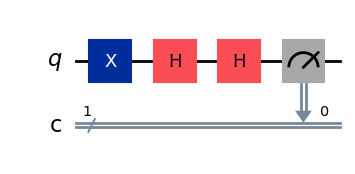

In [1]:
## Part 1 — Quantum Circuit for MZI with Vertical Incidence

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister  # Import Qiskit core classes

qr = QuantumRegister(1, 'q')   # Create 1 quantum register with 1 qubit, labeled 'q'; represents the which-path degree of freedom
cr = ClassicalRegister(1, 'c') # Create 1 classical register with 1 bit, labeled 'c'; stores the detector measurement result
qc = QuantumCircuit(qr, cr)    # Assemble quantum and classical registers into a circuit object

qc.x(0)    # X gate (Pauli-X / NOT gate): flips |0> -> |1>; represents the photon entering from the *vertical* input port of the first beam splitter
qc.h(0)    # Hadamard gate (1st beam splitter, BS1): maps |1> -> (|0> - |1>)/sqrt(2); photon is split into an equal superposition of upper and lower paths
qc.h(0)    # Hadamard gate (2nd beam splitter, BS2): maps (|0> - |1>)/sqrt(2) -> |1>; two paths recombine and interfere, routing all probability back to the vertical output port
qc.measure(0, 0)  # Measure qubit 0, store result in classical bit 0; represents the detector — which port the photon exits

qc.draw('mpl')  # Render and display the circuit diagram using Matplotlib

### Circuit diagram annotation (element by element)

The circuit produced above contains four elements, each corresponding to a physical component of the MZI:

| Circuit element | Gate / symbol | Physical MZI component | Role |
|---|---|---|---|
| `─[X]─` | Pauli-X (NOT) gate | — | Prepares the photon in the **vertical** input state $|1\rangle$ instead of the default $|0\rangle$ (horizontal) |
| `─[H]─` (1st) | Hadamard gate | **Beam splitter BS1** | Splits the incoming photon equally into two paths: upper arm and lower arm |
| `─[H]─` (2nd) | Hadamard gate | **Beam splitter BS2** | Recombines the two arms; interference determines which output port the photon exits |
| `─[M]─` | Measurement | **Detector** | Records the photon at one of the two output ports |

**State evolution for vertical incidence:**

$$|0\rangle \xrightarrow{X} |1\rangle \xrightarrow{H_{\text{BS1}}} \frac{|0\rangle - |1\rangle}{\sqrt{2}} \xrightarrow{H_{\text{BS2}}} |1\rangle$$

After both beam splitters, the state returns deterministically to $|1\rangle$, so the photon exits from the **vertical output port** with probability 1. This is the constructive interference condition for vertical incidence — the mirror image of the horizontal-incidence case where the photon exits from the horizontal port.

## 2. Simulation code and output. [15 pts.]

Annotate/explain EACH LINE of the code about what the line does. In the output histogram, explain what your histogram means.

Measurement results (counts): {'1': 1024}
Expected: photon exits vertical port (|1>) with probability 1


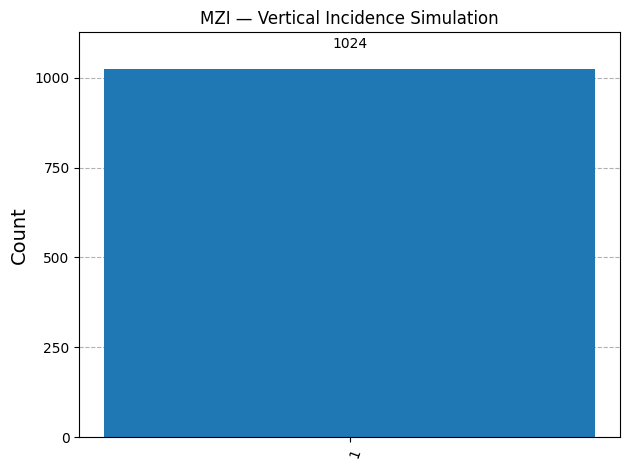

In [2]:
## Part 2 — Simulation with qiskit-aer

from qiskit_aer import AerSimulator          # Import the Aer local simulator backend
from qiskit import transpile                  # Import transpile to compile the circuit for the target backend

simulator = AerSimulator()                    # Instantiate a local statevector / shot-based simulator

compiled_circuit = transpile(qc, simulator)  # Compile (transpile) the circuit to the gate set supported by the simulator

shots = 1024                                               # Number of times to repeat the experiment (shot count)
job = simulator.run(compiled_circuit, shots=shots)         # Submit the compiled circuit to the simulator; returns a job object
result = job.result()                                      # Block until the job completes and retrieve the result object
counts = result.get_counts()                               # Extract the measurement outcome histogram {bitstring: count}

print("Measurement results (counts):", counts)            # Print raw counts
print("Expected: photon exits vertical port (|1>) with probability 1")

# Plot the histogram
from qiskit.visualization import plot_histogram           # Import Qiskit's built-in histogram plotter
plot_histogram(counts, title="MZI — Vertical Incidence Simulation")

### Histogram interpretation

The histogram above shows only a single bar at outcome **`1`** with count **1024 / 1024 (100%)**.

- The x-axis label `1` means the qubit was measured in state $|1\rangle$ — the photon exited from the **vertical output port** of the interferometer.
- The y-axis shows the number of times (out of 1024 shots) that outcome occurred.
- There is **no bar at `0`**, meaning the horizontal output port never fired.

This is the signature of **perfect constructive interference** at the vertical port and **perfect destructive interference** at the horizontal port. It confirms that the MZI circuit behaves exactly as quantum mechanics predicts: a photon entering from the vertical port ($|1\rangle$) passes through BS1, accumulates a relative phase of $-1$ on the $|1\rangle$ component, then recombines at BS2 so that both probability amplitudes add constructively toward $|1\rangle$ and cancel completely toward $|0\rangle$.

3. An image grab of your IBM account home page that shows your name and account API Token (the blue rectangular area at top). [10 pts.]

    Just an image is enough.

![IBM Quantum Account](ibm_account.png)
![1](1.png)
![2](2.png)